Here, we apply normalization/dimensionality reduction/batch correections to the counts matrix:

In [1]:
import time
import os

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.decomposition import PCA

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
import scLEMBAS.utilities as utils


In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load the raw counts matrix (already filtered for low QC cells):

## Covariate Associations

Use the first n_pcs to understand which covariates are most associated with PC variance:

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [5]:
adata.shape

(734650, 16227)

### Cell Cycle Deep Dive

Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.

Let's use a PC component that captures all 3 metrics:

In [6]:
phase_dummies = pd.get_dummies(adata.obs['phase'], prefix='phase').astype(int)
X = pd.concat([adata.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

pca_mod = PCA(n_components=1, random_state = seed)
pca_mod.fit(X) # fit to all 3 metrics

var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

cell_cycle_pc1 = pca_mod.transform(X)
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

Variance explained by PC1 of aggregated cell cycle metrics: 70.677%


Looks like the PC well accounts for all 3 cell cycle metrics, atleast linearly. So, we will use this as our cell cycle covariate.

## Covariate correction

In [7]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


Nonlinear:

In [8]:
import scvi
from scipy import sparse
from lightning.pytorch.loggers import CSVLogger
from tqdm import trange

# from lightning.pytorch.strategies import DDPStrategy

scvi.settings.seed = seed
scvi._settings.ScviConfig.dl_num_workers = n_cores

/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
[rank: 0] Seed set to 888


Initialize and train the model:

In [9]:
# scvi requires raw counts
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))
adata.obs.loc[:, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

scvi.model.SCVI.setup_anndata(
    adata,
    layer = None, 
    categorical_covariate_keys=['plate'],
    continuous_covariate_keys=['pcnt_mito', 'cell_cycle_PC1'],
)
# scvi_mod = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

# logger = CSVLogger(
#     save_dir=os.path.join(data_path, 'interim'),
#     version = 'overwrite',
#     name=author + '_scvi_mod')

# n_gpus = 1
# if n_gpus <= 1 or n_gpus is None:
#     scvi_mod.train(
#         max_epochs = 400, 
#         accelerator = 'gpu', 
#         devices = 1,  
#         early_stopping = True, 
#         early_stopping_patience = 15, 
#         early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
#         batch_size = 4098, 
#         plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
#                      'reduce_lr_on_plateau': True,
#                      'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
#                      'lr_patience': 8,
#                      'lr_factor': 0.6, 
#                      'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
#                     },
#         logger = logger,
#     )
# else:
#     scvi_mod.train(
#         max_epochs = 400, 
#         accelerator = 'gpu', 
#         devices = n_gpus,  
#         early_stopping = True, 
#         early_stopping_patience = 15, 
#         early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
#         batch_size = 4098, 
#         plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
#                      'reduce_lr_on_plateau': True,
#                      'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
#                      'lr_patience': 8,
#                      'lr_factor': 0.6, 
#                      'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
#                     },
#         logger = logger,
#         strategy='ddp_find_unused_parameters_true', 
#     )

# print('Training complete')
# utils.clear_memory()

# print('Save scvi model')
# # qzm, qzv = scvi_mod.get_latent_representation(give_mean=False, return_dist=True)
# # scvi_mod.adata.obsm["X_latent_qzm"] = qzm
# # scvi_mod.adata.obsm["X_latent_qzv"] = qzv

# # scvi_mod.minify_adata()

# scvi_mod.save(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), overwrite=True)
# utils.clear_memory()

print('Load scVI model')
scvi_mod = scvi.model.SCVI.load(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), adata)


Load scVI model
INFO     File /nobackup/users/hmbaghda/scLEMBAS/analysis/processed/Tahoe100M_scvi_mod.scvi/model.pt already        
         downloaded                                                                                                


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nobackup/users/hmbaghda/Software/miniforge3/envs/sc ...


Let's visualize the training results:

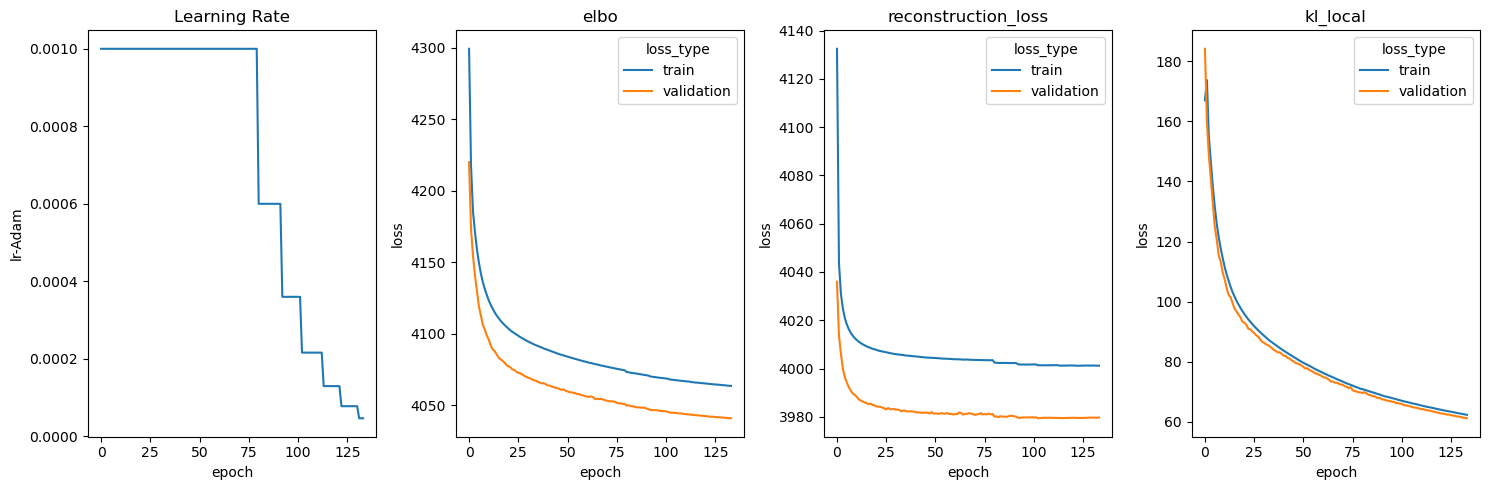

In [57]:
metrics_path = os.path.join(
    data_path, 'interim',
    author + '_scvi_mod',
    'overwrite', # overwrite_2
    'metrics.csv'
)

df = pd.read_csv(metrics_path)
fig, ax = plt.subplots(ncols = 4, figsize = (15, 5))


loss_cols = ['elbo', 'reconstruction_loss']#, 'kl_local']

i = 0
viz_df = df[df['lr-Adam'].notna()][['epoch', 'lr-Adam']]
viz_df.epoch = range(viz_df.shape[0])
sns.lineplot(viz_df, x = 'epoch', y = 'lr-Adam', ax = ax[i])
ax[i].set_title('Learning Rate')


df = df.groupby('epoch').mean()
for i_, loss_type in enumerate(['elbo', 'reconstruction_loss', 'kl_local']):
    i = i+1
    viz_df = df[[loss_type + '_train', loss_type + '_validation']].copy().reset_index()
    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = viz_df.loss_type.apply(lambda x: x.split('_')[-1])
    sns.lineplot(viz_df, x = 'epoch', y = 'loss', hue = 'loss_type', ax = ax[i])
    ax[i].set_title(loss_type)

fig.tight_layout();

# loss_cols = ['elbo', 'reconstruction_loss', 'kl_local']
# df['reconstruction_val_dff'] = df.reconstruction_loss_validation.diff()
# df['kl_val_dff'] = df.kl_local_validation.diff()
# new_cols = ['reconstruction_val_dff', 'kl_val_dff']
# df[[col + '_train' for col in loss_cols] + [col + '_validation' for col in loss_cols] + new_cols].tail(20)


In [10]:
def get_scvi_normalized_expression(
    scvi_mod, 
    n_chunks: int, 
    library_size: float = 1e6, 
    batch_size: int = 1024, 
    sparse_output: bool = False
):
    """
    Runs scvi_mod.get_normalized_expression in memory-efficient chunks,
    aggregates results, and assigns to scvi_mod.adata.X as sparse CSR or dense NumPy array.

    Parameters
    ----------
    scvi_mod : scvi.model.SCVI
        Trained SCVI model.
    n_chunks : int
        Number of chunks to break the data into.
    library_size : float
        Library size for normalization.
    batch_size : int
        Batch size for model prediction.
    sparse_output : bool
        If True, aggregate as sparse CSR; else as dense NumPy array.
    """
    n_obs = scvi_mod.adata.n_obs
    n_vars = scvi_mod.adata.n_vars
    indices = np.arange(n_obs)
    chunk_size = int(np.ceil(n_obs / n_chunks))
    chunks = []

    for i in trange(n_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_obs)
        idx = indices[start:end]
        norm_expr = scvi_mod.get_normalized_expression(
            scvi_mod.adata[idx],
            library_size=library_size,
            batch_size=batch_size
        ).astype('float32').values

        # (Optional) Threshold small values to zero for more sparsity
        # norm_expr[np.abs(norm_expr) < 1e-3] = 0

        if sparse_output:
            chunk = sparse.csr_matrix(norm_expr)
        else:
            chunk = norm_expr
        chunks.append(chunk)
        utils.clear_memory()

    # Stack all chunks
    if sparse_output:
        scvi_mod.adata.X = sparse.vstack(chunks, format='csr')
    else:
        scvi_mod.adata.X = np.vstack(chunks)
    
    return scvi_mod.adata


In [67]:
print('Get counts')
# adata.layers['normalized_counts'] = adata.X.copy()
# this will replace normalized counts with scvi corrected counts
adata = get_scvi_normalized_expression(scvi_mod = scvi_mod,  
                                       n_chunks = 10, 
                                      library_size = 1e6, 
                                      batch_size = 1024)

print('Get latent')
adata.obsm['X_scVI'] = scvi_mod.get_latent_representation(adata)
del adata.layers['counts']
utils.clear_memory()

print('Save anndata object')
adata.write_h5ad(os.path.join(data_path, 'interim', author + '_scvi_counts.h5ad'))

# will have to rerun this once slurm is done

adata.X is the scvi corrected counts, run pc on it

In [74]:
adata.X

array([[2.7666304e+01, 7.8512527e+01, 2.8644020e+01, ..., 9.1725957e-01,
        2.5323956e+00, 5.5995502e+01],
       [1.5680919e+01, 1.4146921e+02, 2.0119383e+01, ..., 1.1386433e+00,
        4.6171176e-01, 3.1232216e+01],
       [1.7181166e+01, 7.4366013e+01, 2.0923422e+01, ..., 1.4064887e+01,
        1.6884737e+00, 6.9410645e+01],
       ...,
       [3.2203138e+00, 9.0379616e+01, 1.8127056e+01, ..., 7.8637707e-01,
        1.8093057e-01, 8.4943924e+01],
       [2.6085966e+00, 8.7053917e+01, 1.2845498e+01, ..., 4.7142720e-01,
        3.1399536e-01, 7.5468353e+01],
       [5.2382064e+00, 2.4190164e+02, 1.4368402e+01, ..., 4.7322240e-01,
        3.1676921e-01, 9.9116829e+01]], dtype=float32)